In [1]:
import numpy as np
import math

E:\anaconda3\envs\tensorflow\lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
E:\anaconda3\envs\tensorflow\lib\site-packages\numpy\.libs\libopenblas.XWYDX2IKJW2NMTWSFYNGFUWKQU3LYTCZ.gfortran-win_amd64.dll
E:\anaconda3\envs\tensorflow\lib\site-packages\numpy\.libs\libopenblas64__v0.3.21-gcc_10_3_0.dll
  warnings.warn("loaded more than 1 DLL from .libs:"


In [2]:
def tanh(x):
    return np.tanh(x)
def softmax(x):
    exp=np.exp(x-x.max())
    return exp/exp.sum()
#实现两个激活函数
#总体框架
#第0层 l` = A (input + b0)
#第1层output = A` (l` * w1 + b1)  两层网络输入28*28平展 l`有784个
#b0:784个
#b1:10个
#w1:[784 * 10]的矩阵

In [3]:
softmax(np.array([1,2,3,4]))

array([0.0320586 , 0.08714432, 0.23688282, 0.64391426])

In [4]:
dimensions=[28*28 , 10]
activation=[tanh,softmax]
distribution=[
    {'b':[0,0]},
    {'b':[0,0],'w':[-math.sqrt(6/(dimensions[0]+dimensions[1])),math.sqrt(6/(dimensions[0]+dimensions[1]))]},
]
#初始化的区间
#第0层b 0 到 0
#第1层b 0 到 0
#第1层w -sqrt(6/(784+10)) 到 sqrt(6/(784+10))

In [5]:
def init_parameters_b(layer):
    dist = distribution[layer]['b']
    return np.random.rand(dimensions[layer])*(dist[1]-dist[0])+dist[0]
def init_parameters_w(layer):
    dist = distribution[layer]['w']
    return np.random.rand(dimensions[layer-1],dimensions[layer])*(dist[1]-dist[0])+dist[0]
#产生在区间dist0 到 dist1 的随机数，来辅助初始化
def init_parameters(): #把所有东西初始化
    parameter=[] #存放初始化后的所有数据
    for i in range(len(distribution)):
        layer_parameter={} #存放初始化后的单层数据
        for j in distribution[i].keys():
            if j == 'b':
                layer_parameter['b']=init_parameters_b(i)
                continue
            if j == 'w':
                layer_parameter['w']=init_parameters_w(i)
                continue
        parameter.append(layer_parameter)
    return parameter

In [6]:
init_parameters_b(0).shape
#第0层b

(784,)

In [7]:
init_parameters_b(1).shape
#第1层b

(10,)

In [8]:
init_parameters_w(1).shape
#第1层w

(784, 10)

In [9]:
parameters=init_parameters() #初始化的参数

In [10]:
def predict(img,parameters): #输入图片和参数
    l0_in = img + parameters[0]['b']
    l0_out=activation[0](l0_in)
    l1_in=np.dot(l0_out,parameters[1]['w'])+parameters[1]['b']  #内积
    l1_out = activation[1](l1_in)
    return l1_out
#前向传播

In [11]:
predict(np.random.rand(784),parameters).argmax() #随即输入，参数也是随机的

2

In [12]:
file_path = "C:\\Users\\haoran\\.keras\\datasets\\mnist.npz"

In [13]:
with np.load(file_path, allow_pickle=True) as data:
    train_image = data['x_train']
    train_label = data['y_train']
    test_image = data['x_test']
    test_label = data['y_test']

In [14]:
train_num=50000 #训练集 
valid_num=10000 #验证集 
test_num=10000  #测试集 
temp_image=train_image
temp_label=train_label
train_image=temp_image[:train_num]
valid_image=temp_image[train_num:]
train_label=temp_label[:train_num]
valid_label=temp_label[train_num:]

In [15]:
import matplotlib.pyplot as plt

In [16]:
def show_train(index):
    plt.imshow(train_image[index],cmap='gray')
    print('label:{}'.format(train_label[index]))
def show_valid(index):
    plt.imshow(valid_image[index],cmap='gray')
    print('label:{}'.format(valid_label[index]))
def show_test(index):
    plt.imshow(test_image[index],cmap='gray')
    print('label:{}'.format(test_label[index]))

label:5


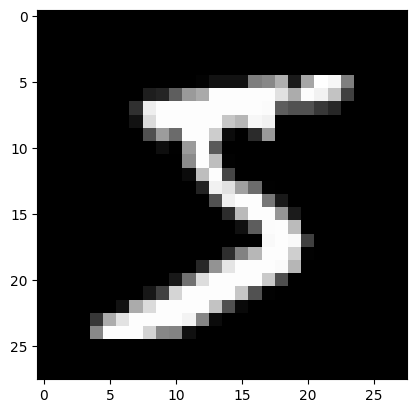

In [19]:
show_train(0)

label:8


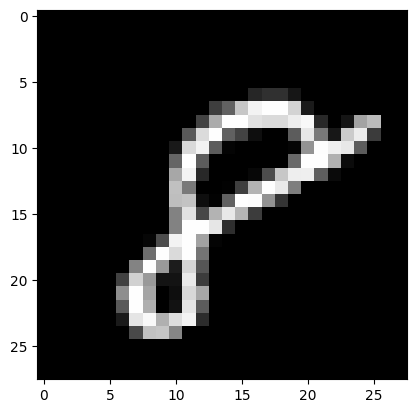

In [18]:
show_valid(9999)